In [ ]:
import pandas as pd
df = pd.read_csv("supermarket_sales.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.shape

(1000, 17)

In [4]:
df.info

<bound method DataFrame.info of       Invoice ID Branch       City Customer type  Gender  \
0    750-67-8428      A     Yangon        Member  Female   
1    226-31-3081      C  Naypyitaw        Normal  Female   
2    631-41-3108      A     Yangon        Normal    Male   
3    123-19-1176      A     Yangon        Member    Male   
4    373-73-7910      A     Yangon        Normal    Male   
..           ...    ...        ...           ...     ...   
995  233-67-5758      C  Naypyitaw        Normal    Male   
996  303-96-2227      B   Mandalay        Normal  Female   
997  727-02-1313      A     Yangon        Member    Male   
998  347-56-2442      A     Yangon        Normal    Male   
999  849-09-3807      A     Yangon        Member  Female   

               Product line  Unit price  Quantity   Tax 5%      Total  \
0         Health and beauty       74.69         7  26.1415   548.9715   
1    Electronic accessories       15.28         5   3.8200    80.2200   
2        Home and lifestyle 

In [5]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Unit price <= 0:", (df["Unit price"] <= 0).sum())
print("Total <= 0:", (df["Total"] <= 0).sum())
print("Rating outside 0-10:", ((df["Rating"] < 0) | (df["Rating"] > 10)).sum())

Quantity <= 0: 0
Unit price <= 0: 0
Total <= 0: 0
Rating outside 0-10: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df[["Date", "Time"]].head()

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Day_Name"] = df["Date"].dt.day_name()

df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M").dt.hour

df[["Date", "Year", "Month", "Month_Name", "Day_Name", "Hour"]].head()

,Date,Year,Month,Month_Name,Day_Name,Hour
0,2019-01-05,2019,1,January,Saturday,13
1,2019-03-08,2019,3,March,Friday,10
2,2019-03-03,2019,3,March,Sunday,13
3,2019-01-27,2019,1,January,Sunday,20
4,2019-02-08,2019,2,February,Friday,10


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   str           
 1   Branch                   1000 non-null   str           
 2   City                     1000 non-null   str           
 3   Customer type            1000 non-null   str           
 4   Gender                   1000 non-null   str           
 5   Product line             1000 non-null   str           
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[us]
 11  Time                     1000 non-null   str           
 12  Payment                  1000 non-null   str  

In [10]:
df.to_csv("supermarket_sales_cleaned.csv", index=False)
import os
print(os.path.exists("supermarket_sales_cleaned.csv"))

True


In [11]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,Date,cogs,gross margin percentage,gross income,Rating,Year,Month,Day,Hour
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.00000,1000.0,1000.000000,1000.000000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905,15.379369,6.97270,2019.0,1.993000,15.256000,14.910000
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905,0.508500,4.00000,2019.0,1.000000,1.000000,10.000000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905,5.924875,5.50000,2019.0,1.000000,8.000000,12.000000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905,12.088000,7.00000,2019.0,2.000000,15.000000,15.000000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905,22.445250,8.50000,2019.0,3.000000,23.000000,18.000000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905,49.650000,10.00000,2019.0,3.000000,31.000000,20.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,0.000000,11.708825,1.71858,0.0,0.835254,8.693563,3.186857


In [12]:
df.groupby("Product line")[["Total", "Quantity", "gross income"]].sum().sort_values("Total", ascending=False)

,Total,Quantity,gross income
Product line,,,
Food and beverages,56144.8440,952,2673.5640
Sports and travel,55122.8265,920,2624.8965
Electronic accessories,54337.5315,971,2587.5015
Fashion accessories,54305.8950,902,2585.9950
Home and lifestyle,53861.9130,911,2564.8530
Health and beauty,49193.7390,854,2342.5590


In [13]:
df.groupby("Branch")[["Total", "Quantity", "gross income", "Rating"]].agg({
    "Total": "sum",
    "Quantity": "sum",
    "gross income": "sum",
    "Rating": "mean"
}).sort_values("Total", ascending=False)

,Total,Quantity,gross income,Rating
Branch,,,,
C,110568.7065,1831,5265.1765,7.072866
A,106200.3705,1859,5057.1605,7.027059
B,106197.6720,1820,5057.0320,6.818072


In [14]:
monthly_sales = df.groupby("Month_Name")["Total"].sum()
monthly_sales
monthly_sales = df.groupby("Month")["Total"].sum()
monthly_sales

Month
1    116291.868
2     97219.374
3    109455.507
Name: Total, dtype: float64

In [15]:
df.groupby("Customer type")[["Total", "Quantity", "gross income", "Rating"]].agg({
    "Total": "sum",
    "Quantity": "sum",
    "gross income": "sum",
    "Rating": "mean"
}).sort_values("Total", ascending=False)

,Total,Quantity,gross income,Rating
Customer type,,,,
Member,164223.444,2785,7820.164,6.940319
Normal,158743.305,2725,7559.205,7.005210


In [16]:
df.groupby("Payment")[["Total", "Quantity", "gross income"]].sum().sort_values("Total", ascending=False)

,Total,Quantity,gross income
Payment,,,
Cash,112206.570,1896,5343.170
Ewallet,109993.107,1892,5237.767
Credit card,100767.072,1722,4798.432


In [17]:
df[["Unit price", "Quantity", "Total", "gross income", "Rating"]].corr()

,Unit price,Quantity,Total,gross income,Rating
Unit price,1.000000,0.010778,0.633962,0.633962,-0.008778
Quantity,0.010778,1.000000,0.705510,0.705510,-0.015815
Total,0.633962,0.705510,1.000000,1.000000,-0.036442
gross income,0.633962,0.705510,1.000000,1.000000,-0.036442
Rating,-0.008778,-0.015815,-0.036442,-0.036442,1.000000


In [18]:
for col in ["Unit price", "Quantity", "Total", "gross income", "Rating"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers")

Unit price: 0 outliers
Quantity: 0 outliers
Total: 9 outliers
gross income: 9 outliers
Rating: 0 outliers


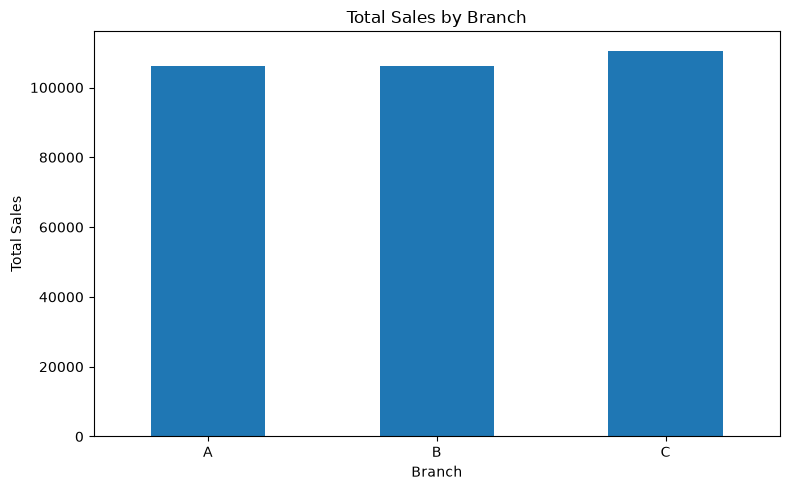

In [20]:
import matplotlib.pyplot as plt

branch_sales = df.groupby("Branch")["Total"].sum()

plt.figure(figsize=(8,5))
branch_sales.plot(kind="bar")
plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

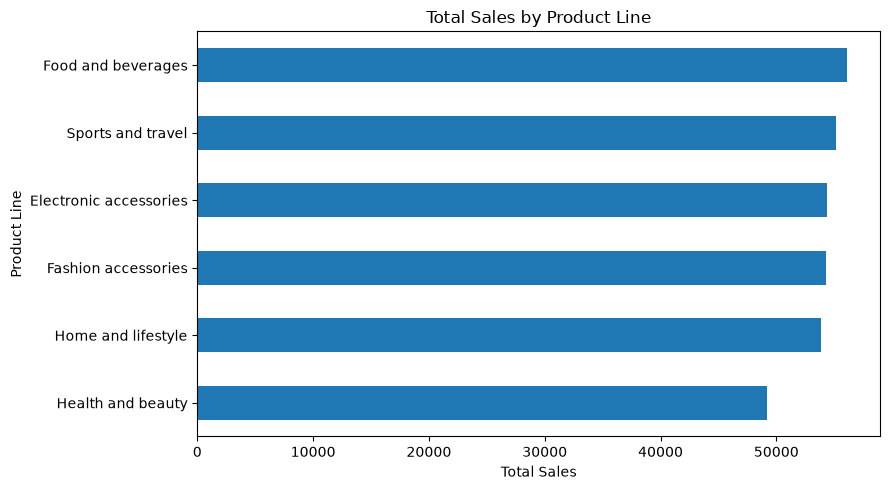

In [21]:
product_sales = df.groupby("Product line")["Total"].sum().sort_values()

plt.figure(figsize=(9,5))
product_sales.plot(kind="barh")
plt.title("Total Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()

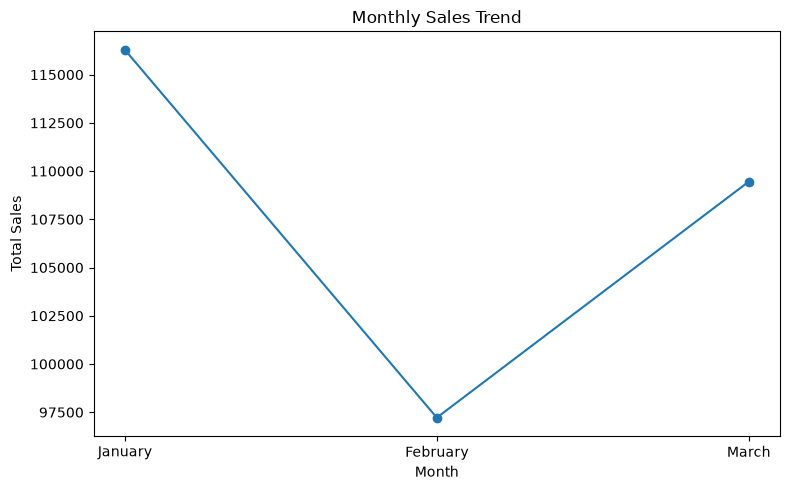

In [22]:
monthly_sales = df.groupby("Month")["Total"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks([1, 2, 3], ["January", "February", "March"])
plt.tight_layout()
plt.show()

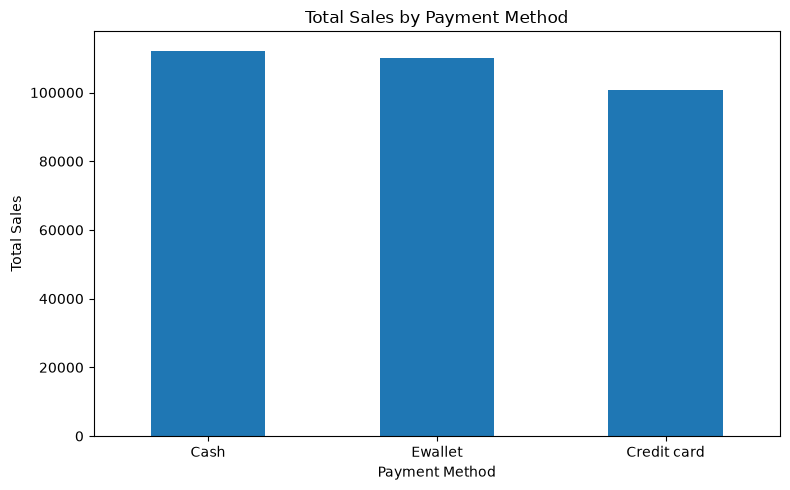

In [23]:
payment_sales = df.groupby("Payment")["Total"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_sales.plot(kind="bar")
plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

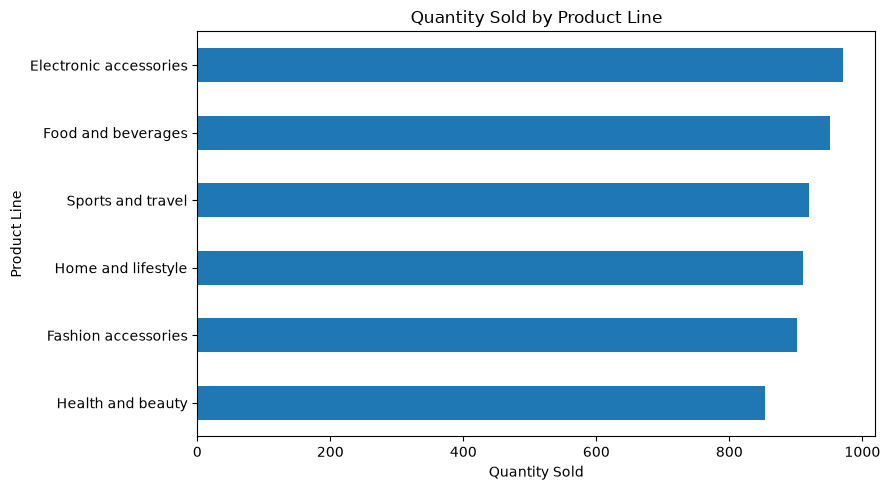

In [24]:
product_quantity = df.groupby("Product line")["Quantity"].sum().sort_values()

plt.figure(figsize=(9,5))
product_quantity.plot(kind="barh")
plt.title("Quantity Sold by Product Line")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()